# Task 3: Domain Generalization (DG) on PACS

This notebook implements the complete, reproducible **Task 3 Domain Generalization** pipeline on **PACS**:
- **Target Domain:** Sketch (strictly quarantined; zero access during training, source diagnostics, checkpoint selection, or hyperparameter selection).
- **Observed Sources:** Photo, Art Painting, Cartoon (Stratified 80/20 train/val split per source domain, seed `6304`).
- **Base Architecture:** torchvision `ResNet-18` (`ResNet18_Weights.IMAGENET1K_V1`) with a 7-class linear head.
- **BatchNorm Policy:** Running mean and variance frozen at ImageNet values; scale ($\gamma$) and bias ($\beta$) trainable.
- **Batch Sampling:** 8 examples per source domain = 24 images per update step.
- **Optimizer:** AdamW ($lr=10^{-4}$, weight decay=$10^{-4}$), max 30 epochs, 5-epoch early stopping on mean source validation macro-F1.
- **Data Restoration:** Downloads `flwrlabs/pacs` directly into `./pacs_data` using the verified Task 2 pipeline.
- **Drive Checkpoint Restoration:** Restores the exact `source_only_erm.pth` baseline checkpoint from `/content/drive/MyDrive/ATML_PA1/Task2/results/checkpoints/source_only_erm.pth`.
- **Methods Evaluated:**
  1. **ERM Baseline:** Reused directly from Task 2.
  2. **DAN-DG:** Pairwise MMD across all source pairs $(P, A)$, $(P, C)$, $(A, C)$ using RBF kernels with bandwidth multipliers $0.5, 1.0, 2.0 \times$ median distance ($\lambda_{\text{DG}} = 1.0$).
  3. **SAM:** Non-adaptive Sharpness-Aware Minimization searching for flat loss minima via two-step normalized gradient perturbations ($\rho = 0.05$).
- **Standardized Diagnostics:**
  - Mean and worst-source validation accuracy and macro-F1.
  - 3-way multinomial logistic regression source separability score ($C=1$, 70/30 split, seed `6304`, $33.33\%$ chance).
  - Standardized loss sharpness proxy $\Delta_{\text{sharp}} = \mathcal{L}_{\text{val}}(\theta + \epsilon) - \mathcal{L}_{\text{val}}(\theta)$ on exactly 32 examples per source domain.
  - Controlled design study varying SAM perturbation radius $\rho \in \{0.01, 0.05, 0.1\}$.
  - Final locked evaluation on Sketch (accuracy, macro-F1, per-class breakdown, dominant confusions, and $\Delta$ vs. ERM).

## 1. Directory Structure Initialization

In [ ]:
import os
import sys

if "." not in sys.path:
    sys.path.insert(0, ".")

TASK3_DIRS = [
    "shared/splits",
    "task2/results/checkpoints",
    "task3/configs",
    "task3/models",
    "task3/methods",
    "task3/selection",
    "task3/evaluation",
    "task3/results/checkpoints",
    "task3/results/curves",
    "pacs_data"
]
for d in TASK3_DIRS:
    os.makedirs(d, exist_ok=True)

init_files = [
    "shared/__init__.py",
    "task3/__init__.py",
    "task3/models/__init__.py",
    "task3/methods/__init__.py",
    "task3/selection/__init__.py",
    "task3/evaluation/__init__.py"
]
for init_path in init_files:
    with open(init_path, "a") as f:
        pass

print("Directory scaffold and __init__.py files initialized.")

Directory scaffold and __init__.py files initialized.


## 2. Restore Task 2 ERM Baseline Checkpoint from Google Drive

In [ ]:
import shutil
import torch
from google.colab import drive

drive.mount('/content/drive')

DEST_FILE = "task2/results/checkpoints/source_only_erm.pth"
DRIVE_FILE = "/content/drive/MyDrive/ATML_PA1/Task2/results/checkpoints/source_only_erm.pth"

if os.path.exists(DRIVE_FILE):
    shutil.copyfile(DRIVE_FILE, DEST_FILE)
    print(f"Successfully restored Task 2 baseline from: {DRIVE_FILE}")
    ckpt = torch.load(DEST_FILE, map_location="cpu")
    print("Checkpoint keys verified:", list(ckpt.keys()))
    if "best_val_macro_f1" in ckpt:
        print(f"Source Validation Macro-F1: {ckpt['best_val_macro_f1']:.2f}%")
else:
    print(f"Could not find checkpoint at: {DRIVE_FILE}")
    print("Searching /content/drive/MyDrive/ATML_PA1/Task2 for any checkpoint copies:")
    for root, dirs, files in os.walk("/content/drive/MyDrive/ATML_PA1/Task2"):
        for f in files:
            if f.endswith(".pth"):
                print(" -", os.path.join(root, f))

Mounted at /content/drive
Successfully restored Task 2 baseline from: /content/drive/MyDrive/ATML_PA1/Task2/results/checkpoints/source_only_erm.pth
Checkpoint keys verified: ['backbone', 'classifier', 'epoch', 'best_val_macro_f1']
Source Validation Macro-F1: 94.07%


## 3. Load PACS Dataset into `./pacs_data/`

In [ ]:
!pip install -q datasets

import os
from datasets import load_dataset

PACS_ROOT = "./pacs_data"
DOMAINS = ["photo", "art_painting", "cartoon", "sketch"]
CLASSES = ["dog", "elephant", "giraffe", "guitar", "horse", "house", "person"]

check_counts = [os.path.exists(os.path.join(PACS_ROOT, d)) for d in DOMAINS]
if all(check_counts) and sum(len(os.listdir(os.path.join(PACS_ROOT, d))) for d in DOMAINS) == 28:
    print("PACS dataset already extracted in ./pacs_data/ with all class subdirectories.")
else:
    print("Loading flwrlabs/pacs dataset from Hugging Face Hub...")
    for d in DOMAINS:
        for c in CLASSES:
            os.makedirs(os.path.join(PACS_ROOT, d, c), exist_ok=True)

    hf_dataset = load_dataset("flwrlabs/pacs")
    print("Exporting images to local directory structure (./pacs_data/<domain>/<class>/)...")
    for split_name in hf_dataset.keys():
        split_data = hf_dataset[split_name]
        label_feature = split_data.features.get("label", None)

        for idx, sample in enumerate(split_data):
            img = sample["image"]
            if "domain" in sample:
                domain_val = sample["domain"]
                domain_name = DOMAINS[domain_val] if isinstance(domain_val, int) else str(domain_val).lower()
            else:
                domain_name = split_name.lower()

            label_val = sample["label"]
            if label_feature is not None and hasattr(label_feature, "int2str"):
                class_name = label_feature.int2str(label_val).lower()
            elif isinstance(label_val, int):
                class_name = CLASSES[label_val]
            else:
                class_name = str(label_val).lower()

            if domain_name in ["art", "artpainting", "art_painting"]:
                domain_name = "art_painting"

            if domain_name in DOMAINS and class_name in CLASSES:
                dest_dir = os.path.join(PACS_ROOT, domain_name, class_name)
                img_path = os.path.join(dest_dir, f"{split_name}_{idx:06d}.jpg")
                img.convert("RGB").save(img_path)

    # Clear stale split cache to construct splits from exported files
    if os.path.exists("shared/splits/pacs_sketch_seed6304.json"):
        os.remove("shared/splits/pacs_sketch_seed6304.json")
    print("PACS images successfully prepared in ./pacs_data/.")

Loading flwrlabs/pacs dataset from Hugging Face Hub...


README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  191MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/9991 [00:00<?, ? examples/s]

Exporting images to local directory structure (./pacs_data/<domain>/<class>/)...
PACS images successfully prepared in ./pacs_data/.


## 4. Shared Protocol & Data Loader (`shared/`)

In [ ]:
%%writefile shared/pacs_protocol.py
import random
import numpy as np
import torch

SEED = 6304
TARGET_DOMAIN = "sketch"
SOURCE_DOMAINS = ["photo", "art_painting", "cartoon"]
CLASSES = ["dog", "elephant", "giraffe", "guitar", "horse", "house", "person"]
NUM_CLASSES = len(CLASSES)

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


Writing shared/pacs_protocol.py


In [ ]:
%%writefile shared/pacs.py
import os
import json
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from torchvision.models import ResNet18_Weights
from sklearn.model_selection import StratifiedShuffleSplit
from shared.pacs_protocol import SEED, SOURCE_DOMAINS, TARGET_DOMAIN, CLASSES

weights = ResNet18_Weights.IMAGENET1K_V1
IMAGENET_MEAN = weights.transforms().mean
IMAGENET_STD = weights.transforms().std

TRAIN_TRANSFORM = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

EVAL_TRANSFORM = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

class PACSSubset(Dataset):
    def __init__(self, items, transform=None):
        self.items = items
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, label, domain = self.items[idx]
        img = Image.open(path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, label, domain

def scan_pacs_directory(root_dir):
    domain_items = {d: [] for d in SOURCE_DOMAINS + [TARGET_DOMAIN]}
    for domain in domain_items.keys():
        dom_path = os.path.join(root_dir, domain)
        if not os.path.exists(dom_path):
            continue
        for class_idx, class_name in enumerate(CLASSES):
            class_path = os.path.join(dom_path, class_name)
            if not os.path.exists(class_path):
                continue
            for fname in sorted(os.listdir(class_path)):
                if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                    fpath = os.path.join(class_path, fname)
                    domain_items[domain].append((fpath, class_idx, domain))
    return domain_items

def build_or_load_splits(root_dir="./pacs_data", splits_json_path="shared/splits/pacs_sketch_seed6304.json"):
    if os.path.exists(splits_json_path):
        with open(splits_json_path, "r") as f:
            split_records = json.load(f)
    else:
        domain_items = scan_pacs_directory(root_dir)
        split_records = {"source_train": {}, "source_val": {}, "target_all": []}

        for d in SOURCE_DOMAINS:
            items = domain_items[d]
            labels = [it[1] for it in items]
            sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
            train_idx, val_idx = next(sss.split(items, labels))

            split_records["source_train"][d] = [items[i] for i in train_idx]
            split_records["source_val"][d] = [items[i] for i in val_idx]

        split_records["target_all"] = domain_items[TARGET_DOMAIN]
        with open(splits_json_path, "w") as f:
            json.dump(split_records, f, indent=2)

    datasets = {
        "source_train": {
            d: PACSSubset(split_records["source_train"][d], transform=TRAIN_TRANSFORM)
            for d in SOURCE_DOMAINS
        },
        "source_val": {
            d: PACSSubset(split_records["source_val"][d], transform=EVAL_TRANSFORM)
            for d in SOURCE_DOMAINS
        },
        "target_adapt": PACSSubset(split_records["target_all"], transform=TRAIN_TRANSFORM),
        "target_eval": PACSSubset(split_records["target_all"], transform=EVAL_TRANSFORM)
    }
    return datasets


Writing shared/pacs.py


## 5. Models & Method Loss Implementations (`task3/`)

In [ ]:
%%writefile task3/models/backbone.py
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

class ResNet18Backbone(nn.Module):
    def __init__(self):
        super().__init__()
        weights = ResNet18_Weights.IMAGENET1K_V1
        net = resnet18(weights=weights)
        self.features = nn.Sequential(*list(net.children())[:-1])
        self.out_features = 512

    def forward(self, x):
        feat = self.features(x)
        return feat.view(feat.size(0), -1)

def freeze_batchnorm_stats(model):
    for m in model.modules():
        if isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
            m.eval()
            m.track_running_stats = False


Writing task3/models/backbone.py


In [ ]:
%%writefile task3/models/classifier_head.py
import torch.nn as nn
from shared.pacs_protocol import NUM_CLASSES

class LinearClassifierHead(nn.Module):
    def __init__(self, in_features=512, num_classes=NUM_CLASSES):
        super().__init__()
        self.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.fc(x)


Writing task3/models/classifier_head.py


In [ ]:
%%writefile task3/methods/dan_dg.py
import torch
import torch.nn as nn

class MMDLoss(nn.Module):
    def __init__(self, bandwidth_multipliers=(0.5, 1.0, 2.0)):
        super().__init__()
        self.multipliers = bandwidth_multipliers

    def compute_pairwise_dist_sq(self, x, y):
        n = x.size(0)
        m = y.size(0)
        x_norm = (x ** 2).sum(dim=1, keepdim=True).expand(n, m)
        y_norm = (y ** 2).sum(dim=1, keepdim=True).expand(m, n).t()
        dist_sq = x_norm + y_norm - 2.0 * torch.mm(x, y.t())
        return torch.clamp(dist_sq, min=0.0)

    def forward(self, source_features, target_features):
        b_s = source_features.size(0)
        b_t = target_features.size(0)
        combined = torch.cat([source_features, target_features], dim=0)

        dist_sq_total = self.compute_pairwise_dist_sq(combined, combined)
        triu_mask = torch.triu(torch.ones_like(dist_sq_total, dtype=torch.bool), diagonal=1)
        pairwise_vals = dist_sq_total[triu_mask]

        median_dist_sq = torch.median(pairwise_vals)
        if median_dist_sq.item() <= 0:
            median_dist_sq = torch.tensor(1.0, device=source_features.device)

        dist_ss = self.compute_pairwise_dist_sq(source_features, source_features)
        dist_tt = self.compute_pairwise_dist_sq(target_features, target_features)
        dist_st = self.compute_pairwise_dist_sq(source_features, target_features)

        k_ss = torch.zeros_like(dist_ss)
        k_tt = torch.zeros_like(dist_tt)
        k_st = torch.zeros_like(dist_st)

        for mult in self.multipliers:
            bandwidth = 2.0 * (mult * median_dist_sq)
            k_ss = k_ss + torch.exp(-dist_ss / bandwidth)
            k_tt = k_tt + torch.exp(-dist_tt / bandwidth)
            k_st = k_st + torch.exp(-dist_st / bandwidth)

        loss_ss = (k_ss.sum() - torch.diagonal(k_ss).sum()) / (b_s * (b_s - 1))
        loss_tt = (k_tt.sum() - torch.diagonal(k_tt).sum()) / (b_t * (b_t - 1))
        loss_st = (2.0 * k_st.sum()) / (b_s * b_t)

        mmd_loss = loss_ss + loss_tt - loss_st
        return torch.clamp(mmd_loss, min=0.0)

class DANDGLoss(nn.Module):
    def __init__(self, lambda_mmd=1.0):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.mmd = MMDLoss(bandwidth_multipliers=(0.5, 1.0, 2.0))
        self.lambda_mmd = lambda_mmd

    def forward(self, source_logits, source_labels, feats_by_domain):
        loss_cls = self.ce(source_logits, source_labels)

        domains = list(feats_by_domain.keys())
        mmd_penalties = []
        for i in range(len(domains)):
            for j in range(i + 1, len(domains)):
                f_i = feats_by_domain[domains[i]]
                f_j = feats_by_domain[domains[j]]
                mmd_penalties.append(self.mmd(f_i, f_j))

        loss_mmd = torch.stack(mmd_penalties).mean()
        total_loss = loss_cls + self.lambda_mmd * loss_mmd
        return total_loss, {
            "loss_cls": loss_cls.item(),
            "loss_mmd": loss_mmd.item(),
            "total_loss": total_loss.item()
        }


Writing task3/methods/dan_dg.py


In [ ]:
%%writefile task3/methods/sam.py
import torch

class SAM(torch.optim.Optimizer):
    def __init__(self, params, base_optimizer, rho=0.05, **kwargs):
        assert rho >= 0.0, f"Invalid rho: {rho}"
        defaults = dict(rho=rho, **kwargs)
        super(SAM, self).__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups = self.base_optimizer.param_groups
        self.defaults.update(self.base_optimizer.defaults)

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group["rho"] / (grad_norm + 1e-12)
            for p in group["params"]:
                if p.grad is None:
                    continue
                self.state[p]["e_w"] = p.grad * scale.to(p)
                p.add_(self.state[p]["e_w"])
        if zero_grad:
            self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None or "e_w" not in self.state[p]:
                    continue
                p.sub_(self.state[p]["e_w"])
        self.base_optimizer.step()
        if zero_grad:
            self.zero_grad()

    def _grad_norm(self):
        shared_device = self.param_groups[0]["params"][0].device
        stack = [
            p.grad.norm(p=2).to(shared_device)
            for group in self.param_groups for p in group["params"]
            if p.grad is not None
        ]
        return torch.norm(torch.stack(stack), p=2)

    def step(self, closure=None):
        raise NotImplementedError("SAM requires two-step optimization: call first_step and second_step.")


Writing task3/methods/sam.py


## 6. Evaluation Modules: Separability & Standardized Sharpness Diagnostics

In [ ]:
%%writefile task3/evaluation/domain_metrics.py
import torch
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from shared.pacs_protocol import SEED, SOURCE_DOMAINS

@torch.no_grad()
def evaluate_domain(backbone, classifier, loader, device):
    backbone.eval()
    classifier.eval()
    all_preds, all_targets = [], []
    for imgs, labels, _ in loader:
        imgs = imgs.to(device)
        feats = backbone(imgs)
        preds = classifier(feats).argmax(dim=1).cpu()
        all_preds.extend(preds.numpy().tolist())
        all_targets.extend(labels.numpy().tolist())
    acc = accuracy_score(all_targets, all_preds) * 100.0
    f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0) * 100.0
    return acc, f1

@torch.no_grad()
def extract_features(backbone, loader, device):
    backbone.eval()
    feats_list = []
    for imgs, _, _ in loader:
        imgs = imgs.to(device)
        feats_list.append(backbone(imgs).cpu())
    return torch.cat(feats_list, dim=0).numpy()

def compute_source_domain_separability(domain_features_dict):
    min_count = min(len(f) for f in domain_features_dict.values())
    rng = np.random.RandomState(SEED)

    x_list, y_list = [], []
    for idx, d in enumerate(SOURCE_DOMAINS):
        feats = domain_features_dict[d]
        chosen = rng.choice(len(feats), size=min_count, replace=False)
        x_list.append(feats[chosen])
        y_list.append(np.full(min_count, idx, dtype=int))

    x = np.concatenate(x_list, axis=0)
    y = np.concatenate(y_list, axis=0)

    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.3, random_state=SEED, stratify=y
    )
    clf = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
    clf.fit(x_train, y_train)
    return float(accuracy_score(y_test, clf.predict(x_test)) * 100.0)

def measure_sharpness_proxy(backbone, classifier, datasets, device, rho=0.05):
    backbone.eval()
    classifier.eval()
    ce = torch.nn.CrossEntropyLoss()

    rng = np.random.RandomState(SEED)
    diag_imgs, diag_labels = [], []

    for d in SOURCE_DOMAINS:
        val_set = datasets["source_val"][d]
        indices = rng.choice(len(val_set), size=32, replace=False)
        for idx in indices:
            img, label, _ = val_set[idx]
            diag_imgs.append(img)
            diag_labels.append(label)

    imgs = torch.stack(diag_imgs, dim=0).to(device)
    labels = torch.tensor(diag_labels, dtype=torch.long, device=device)

    backbone.zero_grad()
    classifier.zero_grad()
    feats = backbone(imgs)
    logits = classifier(feats)
    base_loss = ce(logits, labels)
    base_loss.backward()

    params = [p for p in list(backbone.parameters()) + list(classifier.parameters()) if p.grad is not None]
    grad_norm = torch.norm(torch.stack([p.grad.norm(2) for p in params]), 2)

    perturbations = {}
    with torch.no_grad():
        scale = rho / (grad_norm + 1e-12)
        for p in params:
            e = p.grad * scale
            p.add_(e)
            perturbations[p] = e

    with torch.no_grad():
        pert_feats = backbone(imgs)
        pert_logits = classifier(pert_feats)
        pert_loss = ce(pert_logits, labels)

    with torch.no_grad():
        for p in params:
            p.sub_(perturbations[p])

    return float((pert_loss - base_loss).item())


Writing task3/evaluation/domain_metrics.py


## 7. Task 3 Training Pipeline (`task3/train.py`)

In [ ]:
%%writefile task3/train.py
import os
import sys
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(__file__), "..")))

import copy
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from shared.pacs_protocol import set_seed, SEED, SOURCE_DOMAINS
from shared.pacs import build_or_load_splits
from task3.models.backbone import ResNet18Backbone, freeze_batchnorm_stats
from task3.models.classifier_head import LinearClassifierHead
from task3.methods.dan_dg import DANDGLoss
from task3.methods.sam import SAM
from task3.evaluation.domain_metrics import evaluate_domain

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_task3_model(method="dan_dg", lambda_mmd=1.0, rho=0.05):
    set_seed(SEED)
    datasets = build_or_load_splits("./pacs_data")

    source_train_loaders = {
        d: DataLoader(datasets["source_train"][d], batch_size=8, shuffle=True, drop_last=False, num_workers=2)
        for d in SOURCE_DOMAINS
    }
    source_val_loaders = {
        d: DataLoader(datasets["source_val"][d], batch_size=64, shuffle=False, num_workers=2)
        for d in SOURCE_DOMAINS
    }

    backbone = ResNet18Backbone().to(DEVICE)
    classifier = LinearClassifierHead(in_features=backbone.out_features).to(DEVICE)
    params = list(backbone.parameters()) + list(classifier.parameters())

    max_source_steps = max(len(loader) for loader in source_train_loaders.values())
    total_epochs = 30
    patience = 5
    best_val_macro_f1 = -1.0
    best_weights = None
    no_improve_epochs = 0
    history = {"epochs": [], "loss_cls": [], "loss_mmd": [], "mean_val_f1": []}

    if method == "dan_dg":
        criterion = DANDGLoss(lambda_mmd=lambda_mmd)
        optimizer = torch.optim.AdamW(params, lr=1e-4, weight_decay=1e-4)
    elif method == "sam":
        criterion = nn.CrossEntropyLoss()
        optimizer = SAM(params, torch.optim.AdamW, rho=rho, lr=1e-4, weight_decay=1e-4)
    else:
        raise ValueError(f"Unknown method: {method}")

    print("========================================================")
    print(f"Starting Task 3 Training: {method.upper()} (Max {total_epochs} epochs, {max_source_steps} steps/epoch)")
    print("========================================================")

    for epoch in range(1, total_epochs + 1):
        backbone.train()
        classifier.train()
        freeze_batchnorm_stats(backbone)

        iter_sources = {d: iter(source_train_loaders[d]) for d in SOURCE_DOMAINS}
        ep_cls_loss, ep_mmd_loss = 0.0, 0.0

        for step in range(max_source_steps):
            domain_imgs, domain_labels = {}, {}
            cat_imgs, cat_labels = [], []
            for d in SOURCE_DOMAINS:
                try:
                    imgs, labels, _ = next(iter_sources[d])
                except StopIteration:
                    iter_sources[d] = iter(source_train_loaders[d])
                    imgs, labels, _ = next(iter_sources[d])
                domain_imgs[d] = imgs.to(DEVICE)
                domain_labels[d] = labels.to(DEVICE)
                cat_imgs.append(domain_imgs[d])
                cat_labels.append(domain_labels[d])

            batch_imgs = torch.cat(cat_imgs, dim=0)
            batch_labels = torch.cat(cat_labels, dim=0)

            if method == "dan_dg":
                optimizer.zero_grad()
                feats = backbone(batch_imgs)
                logits = classifier(feats)

                feats_by_dom = {d: feats[i*8:(i+1)*8] for i, d in enumerate(SOURCE_DOMAINS)}
                loss, log_dict = criterion(logits, batch_labels, feats_by_dom)
                loss.backward()
                optimizer.step()

                freeze_batchnorm_stats(backbone)
                ep_cls_loss += log_dict["loss_cls"]
                ep_mmd_loss += log_dict["loss_mmd"]

            elif method == "sam":
                # Forward / Backward pass 1
                feats = backbone(batch_imgs)
                logits = classifier(feats)
                loss1 = criterion(logits, batch_labels)
                loss1.backward()
                optimizer.first_step(zero_grad=True)

                # Forward / Backward pass 2
                freeze_batchnorm_stats(backbone)
                feats2 = backbone(batch_imgs)
                logits2 = classifier(feats2)
                loss2 = criterion(logits2, batch_labels)
                loss2.backward()
                optimizer.second_step(zero_grad=True)

                freeze_batchnorm_stats(backbone)
                ep_cls_loss += loss1.item()

        val_f1s = []
        for d in SOURCE_DOMAINS:
            _, f1 = evaluate_domain(backbone, classifier, source_val_loaders[d], DEVICE)
            val_f1s.append(f1)
        mean_val_f1 = float(np.mean(val_f1s))

        history["epochs"].append(epoch)
        history["loss_cls"].append(ep_cls_loss / max_source_steps)
        history["loss_mmd"].append(ep_mmd_loss / max_source_steps if method == "dan_dg" else 0.0)
        history["mean_val_f1"].append(mean_val_f1)

        print(f"Epoch {epoch:02d} | Cls Loss: {ep_cls_loss/max_source_steps:.4f} | MMD Loss: {ep_mmd_loss/max_source_steps:.4f} | Source Val Mean-F1: {mean_val_f1:.2f}% | Worst: {min(val_f1s):.2f}%")

        if mean_val_f1 > best_val_macro_f1:
            best_val_macro_f1 = mean_val_f1
            best_weights = {
                "backbone": copy.deepcopy(backbone.state_dict()),
                "classifier": copy.deepcopy(classifier.state_dict()),
                "epoch": epoch,
                "best_val_macro_f1": best_val_macro_f1
            }
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1
            if no_improve_epochs >= patience:
                print(f"Early stopping at epoch {epoch} (Best Mean Source-Val Macro-F1: {best_val_macro_f1:.2f}%)")
                break

    ckpt_name = f"{method}_model.pth" if (lambda_mmd == 1.0 and rho == 0.05) else f"{method}_rho_{rho}.pth"
    ckpt_path = os.path.join("task3/results/checkpoints", ckpt_name)
    torch.save(best_weights, ckpt_path)

    curve_path = os.path.join("task3/results/curves", f"{method}_training_curves.json")
    with open(curve_path, "w") as fp:
        json.dump(history, fp, indent=2)

    print(f"Saved checkpoint: {ckpt_path}")
    return ckpt_path

if __name__ == "__main__":
    import argparse
    parser = argparse.ArgumentParser()
    parser.add_argument("--method", choices=["dan_dg", "sam"], required=True)
    parser.add_argument("--lambda_mmd", type=float, default=1.0)
    parser.add_argument("--rho", type=float, default=0.05)
    args = parser.parse_args()
    train_task3_model(method=args.method, lambda_mmd=args.lambda_mmd, rho=args.rho)


Writing task3/train.py


## 8. Final Evaluation on Sketch & Diagnostics Script (`task3/evaluate_sketch.py`)

In [ ]:
%%writefile task3/evaluate_sketch.py
import os
import sys
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(__file__), "..")))

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

from shared.pacs_protocol import SOURCE_DOMAINS, TARGET_DOMAIN, CLASSES
from shared.pacs import build_or_load_splits
from task3.models.backbone import ResNet18Backbone
from task3.models.classifier_head import LinearClassifierHead
from task3.evaluation.domain_metrics import (
    evaluate_domain,
    extract_features,
    compute_source_domain_separability,
    measure_sharpness_proxy
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RESULTS_DIR = "task3/results"

MODELS = {
    "ERM (Baseline)": "task2/results/checkpoints/source_only_erm.pth",
    "DAN-DG": "task3/results/checkpoints/dan_dg_model.pth",
    "SAM": "task3/results/checkpoints/sam_model.pth"
}

def run_task3_final_evaluation():
    datasets = build_or_load_splits("./pacs_data")
    source_val_loaders = {
        d: DataLoader(datasets["source_val"][d], batch_size=64, shuffle=False, num_workers=2)
        for d in SOURCE_DOMAINS
    }
    target_loader = DataLoader(datasets["target_eval"], batch_size=64, shuffle=False, num_workers=2)

    summary_rows = []
    per_class_accuracies = {}
    confusion_dict = {}
    erm_target_acc = None

    for name, ckpt_path in MODELS.items():
        if not os.path.exists(ckpt_path):
            print(f"Skipping {name}: checkpoint {ckpt_path} not found.")
            continue

        backbone = ResNet18Backbone().to(DEVICE)
        classifier = LinearClassifierHead(in_features=backbone.out_features).to(DEVICE)
        ckpt = torch.load(ckpt_path, map_location=DEVICE)
        backbone.load_state_dict(ckpt["backbone"])
        classifier.load_state_dict(ckpt["classifier"])

        # 1. Source evaluations
        src_accs, src_f1s = {}, {}
        src_feats = {}
        for d in SOURCE_DOMAINS:
            acc, f1 = evaluate_domain(backbone, classifier, source_val_loaders[d], DEVICE)
            src_accs[d] = acc
            src_f1s[d] = f1
            src_feats[d] = extract_features(backbone, source_val_loaders[d], DEVICE)

        mean_src_acc = np.mean(list(src_accs.values()))
        worst_src_acc = min(src_accs.values())
        mean_src_f1 = np.mean(list(src_f1s.values()))
        worst_src_f1 = min(src_f1s.values())

        # 2. Source-side diagnostics
        sep_score = compute_source_domain_separability(src_feats)
        sharpness = measure_sharpness_proxy(backbone, classifier, datasets, DEVICE, rho=0.05)

        # 3. Final locked Sketch evaluation
        backbone.eval()
        classifier.eval()
        t_preds, t_targets = [], []
        with torch.no_grad():
            for imgs, labels, _ in target_loader:
                imgs = imgs.to(DEVICE)
                preds = classifier(backbone(imgs)).argmax(dim=1).cpu()
                t_preds.extend(preds.numpy().tolist())
                t_targets.extend(labels.numpy().tolist())

        t_acc = accuracy_score(t_targets, t_preds) * 100.0
        t_f1 = f1_score(t_targets, t_preds, average="macro", zero_division=0) * 100.0

        if name == "ERM (Baseline)":
            erm_target_acc = t_acc
            delta_target = 0.0
        else:
            delta_target = t_acc - erm_target_acc

        cm = confusion_matrix(t_targets, t_preds, labels=list(range(len(CLASSES))))
        confusion_dict[name] = cm
        per_class_accuracies[name] = cm.diagonal() / cm.sum(axis=1) * 100.0

        summary_rows.append({
            "Method": name,
            "Photo Acc": round(src_accs["photo"], 2),
            "Art Acc": round(src_accs["art_painting"], 2),
            "Cartoon Acc": round(src_accs["cartoon"], 2),
            "Mean Source Acc": round(mean_src_acc, 2),
            "Worst Source Acc": round(worst_src_acc, 2),
            "Mean Source F1": round(mean_src_f1, 2),
            "Worst Source F1": round(worst_src_f1, 2),
            "Source Separability (%)": round(sep_score, 2),
            "Loss Sharpness (Proxy)": round(sharpness, 4),
            "Sketch Acc (%)": round(t_acc, 2),
            "Sketch Macro-F1 (%)": round(t_f1, 2),
            "Δ Sketch Acc vs ERM": round(delta_target, 2)
        })

    df_summary = pd.DataFrame(summary_rows)
    df_summary.to_csv(os.path.join(RESULTS_DIR, "task3_dg_benchmark_summary.csv"), index=False)
    print("\n" + "="*100)
    print("TASK 3 DOMAIN GENERALIZATION BENCHMARK SUMMARY")
    print("="*100)
    print(df_summary.to_string(index=False))

    df_classes = pd.DataFrame(per_class_accuracies, index=CLASSES)
    df_classes.to_csv(os.path.join(RESULTS_DIR, "task3_sketch_per_class.csv"))
    print("\n" + "="*80)
    print("PER-CLASS SKETCH ACCURACY (%)")
    print("="*80)
    print(df_classes.round(2).to_string())

    if "ERM (Baseline)" in per_class_accuracies:
        erm_cls = per_class_accuracies["ERM (Baseline)"]
        print("\n" + "="*80)
        print("PER-CLASS SHIFTS & DOMINANT CONFUSIONS RELATIVE TO ERM")
        print("="*80)
        for name in ["DAN-DG", "SAM"]:
            if name not in per_class_accuracies:
                continue
            diffs = per_class_accuracies[name] - erm_cls
            best_idx = np.argmax(diffs)
            worst_idx = np.argmin(diffs)
            print(f"\n[{name}]")
            print(f"  Largest Gain:        {CLASSES[best_idx]} (+{diffs[best_idx]:.2f}%)")
            print(f"  Largest Degradation: {CLASSES[worst_idx]} ({diffs[worst_idx]:.2f}%)")

            cm = confusion_dict[name]
            errs = cm[worst_idx].copy()
            errs[worst_idx] = 0
            dom_err = np.argmax(errs)
            print(f"  Dominant Confusion for '{CLASSES[worst_idx]}': Misclassified as '{CLASSES[dom_err]}' ({errs[dom_err]} samples)")

if __name__ == "__main__":
    run_task3_final_evaluation()


Writing task3/evaluate_sketch.py


## 9. Execute Training: DAN-DG and SAM

In [ ]:
# 1. Train DAN-DG (lambda_mmd = 1.0)
!python3 task3/train.py --method dan_dg --lambda_mmd 1.0

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100% 44.7M/44.7M [00:00<00:00, 58.0MB/s]
Starting Task 3 Training: DAN_DG (Max 30 epochs, 235 steps/epoch)
Epoch 01 | Cls Loss: 0.4729 | MMD Loss: 0.0734 | Source Val Mean-F1: 88.84% | Worst: 82.58%
Epoch 02 | Cls Loss: 0.2205 | MMD Loss: 0.0632 | Source Val Mean-F1: 88.98% | Worst: 83.20%
Epoch 03 | Cls Loss: 0.1571 | MMD Loss: 0.0574 | Source Val Mean-F1: 90.18% | Worst: 84.62%
Epoch 04 | Cls Loss: 0.1157 | MMD Loss: 0.0585 | Source Val Mean-F1: 92.10% | Worst: 89.60%
Epoch 05 | Cls Loss: 0.0866 | MMD Loss: 0.0563 | Source Val Mean-F1: 92.14% | Worst: 90.11%
Epoch 06 | Cls Loss: 0.0956 | MMD Loss: 0.0518 | Source Val Mean-F1: 93.75% | Worst: 90.99%
Epoch 07 | Cls Loss: 0.0690 | MMD Loss: 0.0525 | Source Val Mean-F1: 92.72% | Worst: 88.12%
Epoch 08 | Cls Loss: 0.0749 | MMD Loss: 0.0459 | Source Val Mean-F1: 90.70% | Worst: 85.18%
Epoch 09 | Cls Loss: 0.0

In [ ]:
# 2. Train SAM (rho = 0.05)
!python3 task3/train.py --method sam --rho 0.05

Starting Task 3 Training: SAM (Max 30 epochs, 235 steps/epoch)
Epoch 01 | Cls Loss: 0.6655 | MMD Loss: 0.0000 | Source Val Mean-F1: 90.86% | Worst: 85.93%
Epoch 02 | Cls Loss: 0.2407 | MMD Loss: 0.0000 | Source Val Mean-F1: 93.86% | Worst: 91.57%
Epoch 03 | Cls Loss: 0.1467 | MMD Loss: 0.0000 | Source Val Mean-F1: 92.40% | Worst: 88.61%
Epoch 04 | Cls Loss: 0.1033 | MMD Loss: 0.0000 | Source Val Mean-F1: 94.07% | Worst: 89.62%
Epoch 05 | Cls Loss: 0.0831 | MMD Loss: 0.0000 | Source Val Mean-F1: 93.82% | Worst: 90.76%
Epoch 06 | Cls Loss: 0.0628 | MMD Loss: 0.0000 | Source Val Mean-F1: 94.23% | Worst: 90.04%
Epoch 07 | Cls Loss: 0.0486 | MMD Loss: 0.0000 | Source Val Mean-F1: 94.05% | Worst: 91.73%
Epoch 08 | Cls Loss: 0.0359 | MMD Loss: 0.0000 | Source Val Mean-F1: 94.64% | Worst: 92.28%
Epoch 09 | Cls Loss: 0.0324 | MMD Loss: 0.0000 | Source Val Mean-F1: 94.51% | Worst: 91.55%
Epoch 10 | Cls Loss: 0.0217 | MMD Loss: 0.0000 | Source Val Mean-F1: 94.53% | Worst: 90.51%
Epoch 11 | Cls Lo

## 10. Execute Evaluation: Benchmark Report on Sketch

In [ ]:
# Run locked evaluation across ERM (Baseline), DAN-DG, and SAM
!python3 task3/evaluate_sketch.py


TASK 3 DOMAIN GENERALIZATION BENCHMARK SUMMARY
        Method  Photo Acc  Art Acc  Cartoon Acc  Mean Source Acc  Worst Source Acc  Mean Source F1  Worst Source F1  Source Separability (%)  Loss Sharpness (Proxy)  Sketch Acc (%)  Sketch Macro-F1 (%)  Δ Sketch Acc vs ERM
ERM (Baseline)      97.01    89.76        95.95            94.24             89.76           94.07            89.41                    87.38                  0.3897           74.96                76.97                 0.00
        DAN-DG      96.41    91.71        93.82            93.98             91.71           94.09            91.75                    73.09                  0.2940           70.83                73.66                -4.12
           SAM      98.20    92.68        94.88            95.26             92.68           95.31            92.60                    86.38                  0.0789           74.65                75.44                -0.31

PER-CLASS SKETCH ACCURACY (%)
          ERM (Baseline)  DAN

## 11. Controlled Design Study: SAM Perturbation Radius $\rho \in \{0.01, 0.05, 0.1\}$

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

from shared.pacs import build_or_load_splits
from shared.pacs_protocol import SOURCE_DOMAINS
from task3.models.backbone import ResNet18Backbone
from task3.models.classifier_head import LinearClassifierHead
from task3.train import train_task3_model
from task3.evaluation.domain_metrics import evaluate_domain, measure_sharpness_proxy

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
datasets = build_or_load_splits("./pacs_data")
source_val_loaders = {
    d: DataLoader(datasets["source_val"][d], batch_size=64, shuffle=False, num_workers=2)
    for d in SOURCE_DOMAINS
}
target_loader = DataLoader(datasets["target_eval"], batch_size=64, shuffle=False, num_workers=2)

print("Formulating prior hypothesis before evaluating:")
print("1. Sharpness proxy will monotonically decrease as rho increases from 0.01 to 0.1.")
print("2. Source validation Macro-F1 will slightly decrease as perturbation regularizes parameters away from sharp empirical minima.")
print("3. Sketch generalization will show optimal trade-off at rho=0.05, while rho=0.1 risks over-smoothing class boundaries.")

study_records = []
for rho_val in [0.01, 0.05, 0.1]:
    print(f"\nEvaluating SAM with rho = {rho_val}...")
    ckpt_path = train_task3_model(method="sam", rho=rho_val)

    backbone = ResNet18Backbone().to(DEVICE)
    classifier = LinearClassifierHead(in_features=backbone.out_features).to(DEVICE)
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    backbone.load_state_dict(ckpt["backbone"])
    classifier.load_state_dict(ckpt["classifier"])

    src_f1s = [evaluate_domain(backbone, classifier, source_val_loaders[d], DEVICE)[1] for d in SOURCE_DOMAINS]
    mean_src_f1 = np.mean(src_f1s)
    worst_src_f1 = min(src_f1s)
    sharpness = measure_sharpness_proxy(backbone, classifier, datasets, DEVICE, rho=rho_val)
    t_acc, t_f1 = evaluate_domain(backbone, classifier, target_loader, DEVICE)

    study_records.append({
        "SAM rho": rho_val,
        "Mean Source F1 (%)": round(mean_src_f1, 2),
        "Worst Source F1 (%)": round(worst_src_f1, 2),
        "Loss Sharpness": round(sharpness, 4),
        "Sketch Acc (%)": round(t_acc, 2),
        "Sketch Macro-F1 (%)": round(t_f1, 2),
        "Δ vs ERM (74.96%)": round(t_acc - 74.96, 2)
    })

df_sam_study = pd.DataFrame(study_records)
df_sam_study.to_csv("task3/results/sam_rho_study.csv", index=False)
print("\n" + "="*80)
print("CONTROLLED STUDY: SAM PERTURBATION RADIUS rho in {0.01, 0.05, 0.1}")
print("="*80)
display(df_sam_study)

Formulating prior hypothesis before evaluating:
1. Sharpness proxy will monotonically decrease as rho increases from 0.01 to 0.1.
2. Source validation Macro-F1 will slightly decrease as perturbation regularizes parameters away from sharp empirical minima.
3. Sketch generalization will show optimal trade-off at rho=0.05, while rho=0.1 risks over-smoothing class boundaries.

Evaluating SAM with rho = 0.01...
Starting Task 3 Training: SAM (Max 30 epochs, 235 steps/epoch)
Epoch 01 | Cls Loss: 0.4569 | MMD Loss: 0.0000 | Source Val Mean-F1: 90.52% | Worst: 86.30%
Epoch 02 | Cls Loss: 0.2067 | MMD Loss: 0.0000 | Source Val Mean-F1: 91.98% | Worst: 88.51%
Epoch 03 | Cls Loss: 0.1226 | MMD Loss: 0.0000 | Source Val Mean-F1: 93.01% | Worst: 88.55%
Epoch 04 | Cls Loss: 0.0910 | MMD Loss: 0.0000 | Source Val Mean-F1: 88.79% | Worst: 82.70%
Epoch 05 | Cls Loss: 0.0891 | MMD Loss: 0.0000 | Source Val Mean-F1: 93.32% | Worst: 91.30%
Epoch 06 | Cls Loss: 0.0559 | MMD Loss: 0.0000 | Source Val Mean-F1

,SAM rho,Mean Source F1 (%),Worst Source F1 (%),Loss Sharpness,Sketch Acc (%),Sketch Macro-F1 (%),Δ vs ERM (74.96%)
0,0.01,95.04,93.54,0.0327,59.43,58.76,-15.53
1,0.05,95.31,92.60,0.0789,74.65,75.44,-0.31
2,0.10,94.55,91.97,0.2438,63.35,65.27,-11.61


## 12. Plotting Training Curves

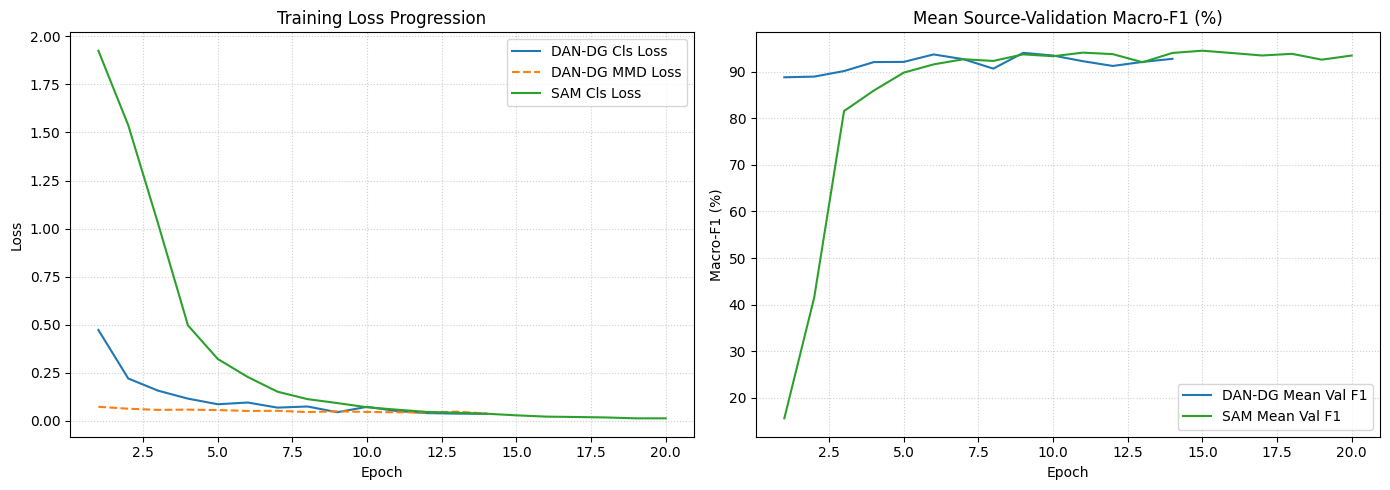

In [ ]:
import json
import os
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dan_curve_path = "task3/results/curves/dan_dg_training_curves.json"
sam_curve_path = "task3/results/curves/sam_training_curves.json"

if os.path.exists(dan_curve_path):
    with open(dan_curve_path, "r") as fp:
        dan_data = json.load(fp)
    axes[0].plot(dan_data["epochs"], dan_data["loss_cls"], label="DAN-DG Cls Loss", color="tab:blue")
    axes[0].plot(dan_data["epochs"], dan_data["loss_mmd"], label="DAN-DG MMD Loss", color="tab:orange", linestyle="--")
    axes[1].plot(dan_data["epochs"], dan_data["mean_val_f1"], label="DAN-DG Mean Val F1", color="tab:blue")

if os.path.exists(sam_curve_path):
    with open(sam_curve_path, "r") as fp:
        sam_data = json.load(fp)
    axes[0].plot(sam_data["epochs"], sam_data["loss_cls"], label="SAM Cls Loss", color="tab:green")
    axes[1].plot(sam_data["epochs"], sam_data["mean_val_f1"], label="SAM Mean Val F1", color="tab:green")

axes[0].set_title("Training Loss Progression")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, linestyle=":", alpha=0.6)
axes[0].legend()

axes[1].set_title("Mean Source-Validation Macro-F1 (%)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro-F1 (%)")
axes[1].grid(True, linestyle=":", alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.savefig("task3/results/curves/task3_training_progression.png", dpi=300)
plt.show()

## 13. Sync Task 3 Results to Google Drive

In [ ]:
import os
import shutil

target_drive_task3 = "/content/drive/MyDrive/ATML_PA1/Task3"
os.makedirs(target_drive_task3, exist_ok=True)

shutil.copytree("task3", target_drive_task3, dirs_exist_ok=True)
print(f"Successfully synced 'task3' -> '{target_drive_task3}'")

zip_archive_path = os.path.join(target_drive_task3, "task3_complete_backup")
shutil.make_archive(zip_archive_path, "zip", root_dir=".", base_dir="task3")
print(f"Task 3 Archive generated at: {zip_archive_path}.zip")

Successfully synced 'task3' -> '/content/drive/MyDrive/ATML_PA1/Task3'
Task 3 Archive generated at: /content/drive/MyDrive/ATML_PA1/Task3/task3_complete_backup.zip
